## configuration done on collab

In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b116e7a6bd1da16a3ddec80f166f673b"

In [4]:
!pip install -q kaggle

[sudo] password for omar: 
sudo: a password is required
^C


In [3]:
!kaggle datasets download -d innominate817/hagrid-sample-30k-384p

/bin/bash: line 1: kaggle: command not found


In [29]:
!unzip -q -o /content/hagrid-sample-30k-384p.zip -d /content/hagrid_dataset/

## importing libraries

In [ ]:
import os
import random
import shutil
import numpy as np
import json

## seeing the json file sturcture

In [ ]:


path = "/content/hagrid_dataset/hagrid-sample-30k-384p/ann_train_val/fist.json"

with open(path, "r") as f:
    data = json.load(f)

# Show one annotation
first_id = next(iter(data))

print("Image ID:")
print(first_id)

print("\nAnnotation:")
print(data[first_id])

Image ID:
003a238e-6ea2-48b0-ad4c-462f9dc655df

Annotation:
{'bboxes': [[0.62957251, 0.39665797, 0.20516206, 0.16012795]], 'labels': ['fist'], 'leading_hand': 'right', 'leading_conf': 0.8, 'user_id': 'b79fa61074d12fdac1e695233d33143715fa505c2bf6b90edd40a75107e89233'}


## creating a data.yaml file

In [ ]:
import json
import os
import shutil
import random
from pathlib import Path


# PATHS


BASE = Path("/content/hagrid_dataset/hagrid-sample-30k-384p")

IMAGE_DIR = BASE / "hagrid_30k"
ANNOTATION_DIR = BASE / "ann_train_val"

OUTPUT = Path("/content/hagrid_dataset/working/yolo_dataset")


# ONLY TWO GESTURES


GESTURES = {
    "palm": 0,
    "peace": 1
}


# CREATE YOLO FOLDERS


for split in ["train", "val", "test"]:

    (OUTPUT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (OUTPUT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )


# FIND ALL IMAGES FOR EACH GESTURE


for gesture, class_id in GESTURES.items():

    print(f"\nProcessing: {gesture}")

    
    # Load JSON
    

    json_path = ANNOTATION_DIR / f"{gesture}.json"

    with open(json_path, "r") as f:
        annotations = json.load(f)

    print(f"Annotations: {len(annotations)}")

    
    # Find images
    

    gesture_dir = IMAGE_DIR / f"train_val_{gesture}"

    image_files = []

    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        image_files.extend(gesture_dir.glob(ext))

    print(f"Images found: {len(image_files)}")

    
    # Make sure images actually exist
    

    if len(image_files) == 0:

        print("WARNING: No images found!")
        print("Expected images in:")
        print(gesture_dir)

        continue

    
    # Match images with JSON annotations
    

    samples = []

    for image_path in image_files:

        image_id = image_path.stem

        if image_id not in annotations:
            continue

        annotation = annotations[image_id]

        bboxes = annotation["bboxes"]
        labels = annotation["labels"]

        # Get only boxes belonging to this gesture
        boxes = []

        for bbox, label in zip(bboxes, labels):

            if label == gesture:
                boxes.append(bbox)

        if len(boxes) == 0:
            continue

        samples.append(
            (image_path, boxes)
        )

    print(f"Matched images: {len(samples)}")

    
    # SHUFFLE
    

    random.seed(42)
    random.shuffle(samples)

    
    # SPLIT
    #
    # 80% train
    # 10% val
    # 10% test
    

    n = len(samples)

    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    split_data = {
        "train": samples[:train_end],
        "val": samples[train_end:val_end],
        "test": samples[val_end:]
    }

    
    # CREATE YOLO DATA
    

    for split, split_samples in split_data.items():

        for image_path, boxes in split_samples:

            image_id = image_path.stem

            
            # Create symlink instead of copying image
            

            output_image = (
                OUTPUT
                / "images"
                / split
                / image_path.name
            )

            if not output_image.exists():

                os.symlink(
                    image_path,
                    output_image
                )

            
            # Create YOLO label
           

            label_path = (
                OUTPUT
                / "labels"
                / split
                / f"{image_id}.txt"
            )

            with open(label_path, "w") as f:

                for bbox in boxes:

                    x, y, w, h = bbox

                    f.write(
                        f"{class_id} "
                        f"{x} {y} {w} {h}\n"
                    )

        print(
            f"{split}: "
            f"{len(split_samples)} images"
        )


# CREATE data.yaml

yaml_content = f"""path: {OUTPUT}

train: images/train
val: images/val
test: images/test

names:
  0: palm
  1: peace
"""

yaml_path = OUTPUT / "data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)


print("\n========================================")
print("YOLO DATASET CREATED")
print("========================================")

print(f"Dataset: {OUTPUT}")
print(f"YAML:    {yaml_path}")

for split in ["train", "val", "test"]:

    image_count = len(
        list(
            (OUTPUT / "images" / split).iterdir()
        )
    )

    label_count = len(
        list(
            (OUTPUT / "labels" / split).iterdir()
        )
    )

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )

print("\nDATA.YAML:")
print(yaml_content)


Processing: palm
Annotations: 28326
Images found: 1770
Matched images: 1770
train: 1416 images
val: 177 images
test: 177 images

Processing: peace
Annotations: 28303
Images found: 1769
Matched images: 1769
train: 1415 images
val: 177 images
test: 177 images

YOLO DATASET CREATED
Dataset: /content/hagrid_dataset/working/yolo_dataset
YAML:    /content/hagrid_dataset/working/yolo_dataset/data.yaml
train: 2831 images, 2831 labels
val: 354 images, 354 labels
test: 354 images, 354 labels

DATA.YAML:
path: /content/hagrid_dataset/working/yolo_dataset

train: images/train
val: images/val
test: images/test

names:
  0: palm
  1: peace



## training the model

In [35]:
from ultralytics import YOLO

model = YOLO("/content/yolo26s.pt")

model.train(
    data="/content/hagrid_dataset/working/yolo_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hagrid_dataset/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a1da0ea0750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## testing on a sample


image 1/1 /content/hagrid_dataset/working/yolo_dataset/images/test/0259e4c4-7220-4fdf-b7a6-df34896db45b.jpg: 480x640 2 palms, 13.0ms
Speed: 4.2ms preprocess, 13.0ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


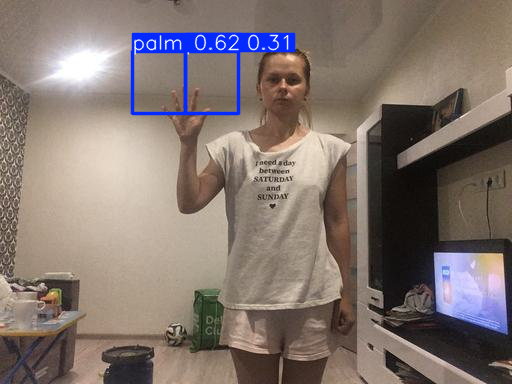

In [ ]:
import matplotlib.pyplot as plt

# Load your trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Pick one test image
image_path = "/content/hagrid_dataset/working/yolo_dataset/images/test/0259e4c4-7220-4fdf-b7a6-df34896db45b.jpg"

# Run YOLO
results = model(image_path)

# Display result
results[0].show()

In [39]:
result = results[0]

for box in result.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x, y, w, h = box.xywh[0].tolist()

    print("Gesture:", result.names[class_id])
    print("Confidence:", confidence)
    print("X center:", x)
    print("Y center:", y)
    print("Width:", w)
    print("Height:", h)

Gesture: palm
Confidence: 0.6200352311134338
X center: 158.75485229492188
Y center: 82.62091064453125
Width: 53.11372375488281
Height: 61.90729522705078
Gesture: palm
Confidence: 0.31335553526878357
X center: 212.08592224121094
Y center: 82.66168212890625
Width: 53.590667724609375
Height: 62.477909088134766


# This model outputs position ,width , height ,and confidence for each frame 


# load the model directly it is already trained 